<a href="https://colab.research.google.com/github/gabrielcarcedo/Taller-aprendizaje-automatico-para-procesamiento-de-datos/blob/main/D%C3%ADa%205/Taller_ML_DL_IIMAS_UNAM_D%C3%ADa_5_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller: aprendizaje automático para procesamiento de datos**
---
<table>
  <tr>
    <td width="80%" valign="top">
      <!-- Content for Column 1 -->
      <h4>
      Ing. Gabriel Carcedo Rodríguez: <a href= "mailto:gabrielcarcedo@comunidad.unam.mx">gabrielcarcedo@comunidad.unam.mx</a>
      <br>
      <br>
      Dra. Nidiyare Hevia Montiel: <a href= "mailto:nidiyare.hevia@iimas.unam.mx">nidiyare.hevia@iimas.unam.mx</a>
      <br>
      <br>
      Dra. Blanca Vázquez Gómez: <a href= "mailto:blanca.vazquez@iimas.unam.mx">blanca.vazquez@iimas.unam.mx</a></h4>
    </td>
    <td width="20%" valign="top">
      <!-- Content for Column 2 -->
      <a href="https://arbioiimas.github.io/ArBio"><img src="https://arbioiimas.github.io/ArBio/images/logo_arbio.png" alt="Artificial Intelligence in Biomedicine Group (ArBio)" style="width:80%; height:auto;"></a>
    </td>
  </tr>
  <tr>
    <td width="80%" valign="top">
      <!-- Content for Column 1 -->
      <h4>Programa impartido por el <a href="https://www.iimas.unam.mx/">Instituto de Investigaciones en Matemáticas Aplicadas y en Sistemas, IIMAS, UNAM</a>.
      <br>
      <br>
      Para mayor información visite el <a href="https://www.iimas.unam.mx/educacioncontinua/curso_deep_learning.html">sitio oficial</a>.
    </td>
    <td width="20%" valign="top">
      <!-- Content for Column 2 -->
      <a href="https://www.iimas.unam.mx/educacioncontinua/"><img src="https://www.iimas.unam.mx/educacioncontinua/images/logo.svg" alt="Educación Continua, IIMAS, UNAM" style="width:100%; height:auto;"></a></h4>
    </td>
  </tr>
</table>

---
---
## **Objetivo de esta Notebook**:

* Implementar un Autoencoder Variacional para reconstrucción
---

Variational Autoencoder (VAE) con MNIST: https://projector.tensorflow.org/

# Base de Datos MNIST

La base de datos MNIST (Modified National Institute of Standards and Technology database) es uno de los conjuntos de datos más emblemáticos en el campo del aprendizaje automático y la visión por computadora. Se utiliza ampliamente para entrenar y evaluar algoritmos de clasificación, especialmente en el reconocimiento de dígitos manuscritos. A continuación, se presenta un resumen de su historia y características clave.

## Orígenes e Historia

- **Origen en el NIST:**  
  La base original fue compilada por el NIST (Instituto Nacional de Estándares y Tecnología de Estados Unidos) en la década de 1990, reuniendo una gran cantidad de dígitos manuscritos extraídos de formularios y documentos administrativos.

- **Transformación a MNIST:**  
  Para superar desafíos como las variaciones en tamaño, posición y orientación de los dígitos, investigadores como Yann LeCun, Corinna Cortes y Christopher J.C. Burges aplicaron técnicas de preprocesamiento (normalización, centrado y redimensionamiento) a las imágenes. Este proceso dio origen al dataset MNIST, que resultó en imágenes más homogéneas y fáciles de manejar para los algoritmos de machine learning.

## Características Principales

- **Contenido del Dataset:**  
  MNIST consta de 70,000 imágenes en escala de grises de dígitos manuscritos, divididas en 60,000 imágenes para entrenamiento y 10,000 para prueba.

- **Formato de las Imágenes:**  
  Cada imagen tiene un tamaño de 28x28 píxeles, lo que permite que los modelos de clasificación se enfoquen en la tarea de reconocer patrones sin necesidad de una preprocesamiento excesivo.

- **Aplicaciones:**  
  Debido a su simplicidad y consistencia, MNIST se ha convertido en un benchmark fundamental para probar y comparar diversas arquitecturas de redes neuronales y algoritmos de reconocimiento de patrones.




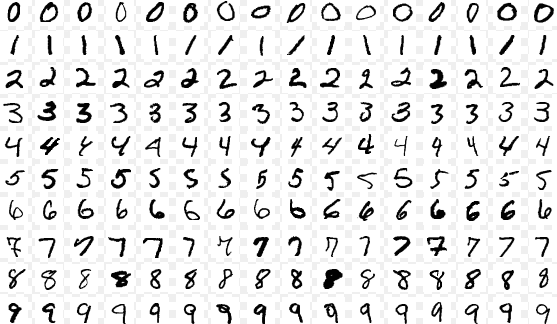

# **¿Cómo funcionan los Autoencoders?**

Un **autoencoder** es una red neuronal que aprende a **comprimir y luego reconstruir** datos.

### Fases del autoencoder:
1. **Encoder** (*Codificador*): reduce una imagen a una representación comprimida llamada *vector latente*.
2. **Latent space** (*Espacio latente*): es un espacio en el que se representan las características más importantes de la imagen.
3. **Decoder** (*Decodificador*): toma esa representación comprimida y genera una imagen que intenta parecerse lo más posible a la original.

---





# **¿Cómo se entrena un autoencoder?**

Durante el entrenamiento:
- Se le da una imagen como entrada.
- El encoder la comprime.
- El decoder trata de reconstruirla.
- Se calcula un **error de reconstrucción**: qué tan distinta es la imagen predicha respecto a la original.
- Ese error se usa para ajustar los pesos de la red.

---

## **Entrada**

Imagen del dataset MNIST.

---

## **Encoder**

Toma la imagen de entrada y produce dos vectores:

🔹 **`z_mean`**  
→ Representa la media de la distribución latente ("punto central" en el espacio latente).

🔹 **`z_log_var`**  
→ Representa la varianza (logarítmica) de la distribución latente. Mide la dispersión de **z**.

Lo que se busca en la reconstrucción es  “Esta imagen debería estar cerca de este punto (z_mean), con algo de variabilidad (z_log_var).”

---
## **Sampling**

🔹 **`z = z_mean + ε * exp(0.5 * z_log_var)`**  
→ Se genera un vector `z` muestreando de una distribución gaussiana.  
→ `ε` es un vector de ruido aleatorio con distribución normal (`ε ~ N(0,1)`).

---
### Ejemplo numérico

Supongamos que el encoder nos da lo siguiente para una imagen del MNIST:

- `z_mean = [0.1, 0.3]`
- `z_log_var = [0.2, -0.4]`
- `ε = [1.0, -1.5]` ← generado al azar

Entonces:

```python
σ = exp(0.5 * z_log_var) = [exp(0.1), exp(-0.2)] ≈ [1.105, 0.818]
z = z_mean + ε * σ
  = [0.1, 0.3] + [1.0 * 1.105, -1.5 * 0.818]
  = [0.1 + 1.105, 0.3 - 1.227]
  = [1.205, -0.927]
```
---

## **Decoder**

El decoder toma el vector `z` y trata de reconstruir la imagen.

---

## **Función de pérdida**

🔹 **Pérdida total = Pérdida de reconstrucción + Pérdida KL**

1. **Pérdida de reconstrucción**  
   - Se calcula comparando la imagen original con la reconstruida (píxel a píxel).
   - Se usa, por ejemplo, `binary_crossentropy`.
   - Mide qué tan parecida es la salida a la entrada.

2. **Pérdida KL (Kullback-Leibler)**  
   - Penaliza si la distribución latente se aleja de la distribución del conjunto de datos, como puede ser una distribución normal estándar `N(0,1)`.
   - Ayuda a mantener un espacio latente continuo y útil para generar imágenes nuevas similares a las del conjunto de datos original.

---

Este proceso se repite en cada lote durante el entrenamiento. El objetivo es lograr que el modelo aprenda un espacio latente compacto y bien estructurado donde cada punto pueda generar imágenes realistas.


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import os

# DEFINIR DIRECTORIO PARA GUARDAR MODELOS
save_dir = 'autoencoders'
os.makedirs(save_dir, exist_ok=True)

In [12]:
# CARGAR DATOS MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train.astype('float32') / 255., -1)
x_test = np.expand_dims(x_test.astype('float32') / 255., -1)

In [13]:
latent_dim = 2  # dimensión del espacio latente

In [14]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.keras.backend.random_normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [15]:
# DEFINIR EL ENCODER
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# DEFINIR EL DECODER
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
decoder = Model(latent_inputs, decoder_outputs, name='decoder')

In [16]:
# DEFINIR MODELO VAE PERSONALIZADO
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(tf.reshape(data, [-1, 784]),
                                                    tf.reshape(reconstruction, [-1, 784]))
            ) * 784
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [17]:
# COMPILAR MODELO
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam', loss=lambda y_true, y_pred: 0.0)

In [18]:
# CALLBACK PARA GUARDAR MODELOS CADA N ÉPOCAS
class ModelCheckpointCallback(tf.keras.callbacks.Callback):
    def __init__(self, save_dir, interval=5):
        super().__init__()
        self.save_dir = save_dir
        self.interval = interval

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            weights_path = os.path.join(self.save_dir, f"vae_epoch_{epoch+1}.weights.h5")

            # Forzar que el modelo esté "built" si no lo está
            if not self.model.built:
                dummy_input = tf.zeros((1, 28, 28, 1))  # una imagen de ejemplo
                self.model(dummy_input)

            self.model.save_weights(weights_path)
            print(f"Pesos guardados en: {weights_path}")

In [19]:
# ENTRENAR MODELO
vae.fit(x_train, epochs=5, batch_size=128, callbacks=[ModelCheckpointCallback(save_dir, interval=5)])

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - kl_loss: 2.4700 - loss: 210.7472 - reconstruction_loss: 208.2773
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.7441 - loss: 174.7708 - reconstruction_loss: 171.0267
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.8577 - loss: 165.1083 - reconstruction_loss: 161.2507
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.9238 - loss: 161.1631 - reconstruction_loss: 157.2394
Epoch 5/5
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 3.9530 - loss: 159.2316 - reconstruction_loss: 155.2786Pesos guardados en: autoencoders/vae_epoch_5.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.9572 - loss: 158.7171 - reconstruction_loss: 154.7598


# Inferencia

In [20]:
# DEPENDENCIAS Y LIBRERÍAS
import ipywidgets as widgets
from IPython.display import display, clear_output

In [21]:
weights_files = sorted([f for f in os.listdir(save_dir) if f.endswith('.h5')])

In [25]:
# CONSTRUCCIÓN DEL MODELO
def build_encoder_decoder():
    encoder_inputs = layers.Input(shape=(28, 28, 1))
    e1 = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
    e2 = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(e1)
    flat = layers.Flatten()(e2)
    dense = layers.Dense(16, activation='relu')(flat)
    z_mean = layers.Dense(latent_dim)(dense)
    z_log_var = layers.Dense(latent_dim)(dense)
    z = layers.Lambda(sampling)([z_mean, z_log_var])
    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    encoder_intermediate = Model(encoder_inputs, [e1, e2])

    latent_inputs = layers.Input(shape=(latent_dim,))
    d1 = layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
    reshaped = layers.Reshape((7, 7, 64))(d1)
    d2 = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(reshaped)
    d3 = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(d2)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(d3)
    decoder = Model(latent_inputs, decoder_outputs, name='decoder')
    decoder_intermediate = Model(latent_inputs, [reshaped, d2, d3, decoder_outputs])

    return encoder, encoder_intermediate, decoder, decoder_intermediate

def build_full_vae():
    encoder, encoder_intermediate, decoder, decoder_intermediate = build_encoder_decoder()
    class VAE(Model):
        def __init__(self, encoder, decoder, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
        def call(self, inputs):
            _, _, z = self.encoder(inputs)
            return self.decoder(z)
    vae = VAE(encoder, decoder)
    return vae, encoder, encoder_intermediate, decoder, decoder_intermediate

# FUNCIÓN VISUALIZACIÓN DESDE IMAGEN
def visualize_activations_from_image(image, model_name, encoder, encoder_intermediate, decoder_intermediate):
    encoder_acts = encoder_intermediate.predict(image)
    _, _, z_sample = encoder.predict(image)
    decoder_acts = decoder_intermediate.predict(z_sample)

    print(f"Usando modelo: {model_name}")

    # Imagen original + activaciones encoder
    fig, axs = plt.subplots(1, len(encoder_acts) + 1, figsize=(18, 4))
    axs[0].imshow(image[0, :, :, 0], cmap='gray', interpolation='nearest')
    axs[0].set_title("Imagen original")
    axs[0].set_xlabel("28×28")
    axs[0].get_yaxis().set_visible(False)
    for spine in axs[0].spines.values():
        spine.set_visible(False)

    for i, act in enumerate(encoder_acts):
        act_mean = np.mean(act[0], axis=-1)
        axs[i+1].imshow(act_mean, cmap='gray', interpolation='nearest')
        axs[i+1].set_title(f"Encoder {i+1}")
        img_shape = act_mean.shape  # dimensiones reales (altura, ancho)
        axs[i+1].set_xlabel(f"{img_shape[0]}x{img_shape[1]}")
        axs[i+1].get_yaxis().set_visible(False)
        for spine in axs[i+1].spines.values():
            spine.set_visible(False)
    plt.suptitle("Imagen original + Activaciones del Encoder")
    plt.show()

    print(f"Vector latente z = {z_sample[0]}")

    # Activaciones del decoder
    fig, axs = plt.subplots(1, len(decoder_acts), figsize=(20, 4))
    for i, act in enumerate(decoder_acts):
        act_mean = np.mean(act[0], axis=-1)
        axs[i].imshow(act_mean, cmap='gray', interpolation='nearest')
        axs[i].set_title(f"Decoder {i+1}")
        img_shape = act_mean.shape
        axs[i].set_xlabel(f"{img_shape[0]}x{img_shape[1]}")
        axs[i].get_yaxis().set_visible(False)
        for spine in axs[i].spines.values():
            spine.set_visible(False)
    plt.suptitle("Activaciones del Decoder")
    plt.show()

    # Imagen original vs reconstruida
    reconstructed = decoder_acts[-1]
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(image[0, :, :, 0], cmap='gray', interpolation='nearest')
    axs[0].set_title("Imagen original")
    axs[0].set_xlabel("28x28")
    axs[0].axis('off')
    reconstructed_mean = np.mean(reconstructed[0], axis=-1)
    axs[1].imshow(reconstructed_mean, cmap='gray', interpolation='nearest')
    axs[1].set_title("Reconstruida")
    img_shape = reconstructed_mean.shape
    axs[1].set_xlabel(f"{img_shape[0]}x{img_shape[1]}")
    axs[1].axis('off')
    plt.suptitle("Comparación original vs reconstruida")
    plt.show()

## Ejecutar el **Autoencoder**

In [26]:
# UI INTERACTIVA SEPARADA
model_selector_1 = widgets.Dropdown(options=weights_files, description='Modelo:', layout=widgets.Layout(width='95%'))
model_selector_2 = widgets.Dropdown(options=weights_files, description='Modelo:', layout=widgets.Layout(width='95%'))
button_real = widgets.Button(description="Imagen real (MNIST)", button_style='primary')
button_manual = widgets.Button(description="Vector latente manual", button_style='success')
latent_input_x = widgets.FloatText(value=0.0, description='z[0]:')
latent_input_y = widgets.FloatText(value=0.0, description='z[1]:')

use_index_checkbox = widgets.Checkbox(value=False, description="Usar índice manual")
index_slider = widgets.IntSlider(value=0, min=0, max=len(x_test)-1, description='Índice:')

output_1 = widgets.Output()
output_2 = widgets.Output()

def on_real_clicked(b):
    with output_1:
        clear_output()
        path = os.path.join(save_dir, model_selector_1.value)
        print(f"Cargando modelo: {model_selector_1.value}")
        vae, encoder, encoder_intermediate, decoder, decoder_intermediate = build_full_vae()
        vae(tf.zeros((1, 28, 28, 1)))
        vae.load_weights(path)

        if use_index_checkbox.value:
            idx = index_slider.value
            print(f"Mostrando imagen con índice manual: {idx}")
        else:
            idx = np.random.randint(0, len(x_test))
            print(f"Mostrando imagen aleatoria: {idx}")

        image = x_test[idx:idx+1]
        visualize_activations_from_image(image, model_selector_1.value, encoder, encoder_intermediate, decoder_intermediate)

def on_manual_clicked(b):
    with output_2:
        clear_output()
        path = os.path.join(save_dir, model_selector_2.value)
        print(f"Cargando modelo: {model_selector_2.value}")
        vae, _, _, decoder, decoder_intermediate = build_full_vae()
        vae(tf.zeros((1, 28, 28, 1)))
        vae.load_weights(path)
        z = np.array([[latent_input_x.value, latent_input_y.value]])
        decoder_acts = decoder_intermediate.predict(z)
        fig, axs = plt.subplots(1, len(decoder_acts), figsize=(20, 4))
        for i, act in enumerate(decoder_acts):
            act_mean = np.mean(act[0], axis=-1)
            axs[i].imshow(act_mean, cmap='gray', interpolation='nearest')
            axs[i].set_title(f"Decoder {i+1}")
            img_shape = act_mean.shape
            axs[i].set_xlabel(f"{img_shape[0]}x{img_shape[1]}")
            axs[i].get_yaxis().set_visible(False)
            for spine in axs[i].spines.values():
                spine.set_visible(False)
        plt.suptitle("Decoder desde vector latente (última es la imagen generada)")
        plt.show()

button_real.on_click(on_real_clicked)
button_manual.on_click(on_manual_clicked)

left_box = widgets.VBox([
    widgets.Label("Visualizar imagen real y reconstrucción"),
    model_selector_1, use_index_checkbox, index_slider, button_real, output_1
])
right_box = widgets.VBox([
    widgets.Label("Generar desde vector latente"),
    model_selector_2, latent_input_x, latent_input_y, button_manual, output_2
])

In [28]:
display(widgets.HBox([left_box, right_box]))

### Visualizar el **espacio latente**

Este código se utiliza para analizar la representación latente generada por un modelo Autoencoder Variacional (VAE). A continuación, se describe paso a paso su funcionamiento:

#### ¿Qué son z1 y z2?
- Cuando el espacio latente es de 2 dimensiones (es decir, `latent_dim = 2`), cada imagen se representa mediante un vector de dos componentes: **z1** y **z2**.
- `z1` y `z2` corresponden a las dos coordenadas de este vector latente. Puedes interpretarlas de manera análoga a los ejes *x*, *y* en un plano.
- Estos valores definen la posición de cada imagen en el espacio latente y, al generar una grilla de puntos (por ejemplo, en el rango `[-2, 2]`), es posible visualizar cómo varía la imagen decodificada al moverse en dicho espacio.
- Es importante resaltar que, si bien se pueden etiquetar como *x* e *y*, estas dimensiones no tienen un significado semántico explícito sin un análisis adicional; simplemente son las dos variables que el modelo ha aprendido para representar la variabilidad de los datos.


In [30]:
# Desplegable para seleccionar modelo
latent_model_selector = widgets.Dropdown(
    options=weights_files,  # ya definidos en tu entorno
    description='Modelo:',
    layout=widgets.Layout(width='60%')
)

# Tamaño del grid
grid_size_slider = widgets.IntSlider(value=10, min=5, max=20, step=1, description='Grid size:')

# Rango del espacio latente
x_min = widgets.FloatText(value=-2.0, description='x min:')
x_max = widgets.FloatText(value=2.0, description='x max:')
y_min = widgets.FloatText(value=-2.0, description='y min:')
y_max = widgets.FloatText(value=2.0, description='y max:')

# Botón
generate_button = widgets.Button(description="Visualizar espacio latente")
output_latent = widgets.Output()

# Función para graficar espacio latente
def plot_latent_grid(decoder, n=10, x_range=(-2,2), y_range=(-2,2)):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(x_range[0], x_range[1], n)
    grid_y = np.linspace(y_range[1], y_range[0], n)  # invertido para que se vea natural

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(8, 8))
    plt.imshow(figure, cmap='gray', interpolation='nearest')
    plt.title("Visualización del espacio latente")
    plt.axis('off')
    plt.show()

# Callback
def generate_latent_grid(b):
    with output_latent:
        clear_output()
        model_path = os.path.join(save_dir, latent_model_selector.value)
        print(f"Modelo cargado: {latent_model_selector.value}")

        # Reconstruir y cargar el modelo
        vae, _, _, decoder, _ = build_full_vae()
        vae(tf.zeros((1, 28, 28, 1)))
        vae.load_weights(model_path)

        # Mostrar grilla del espacio latente
        plot_latent_grid(
            decoder,
            n=grid_size_slider.value,
            x_range=(x_min.value, x_max.value),
            y_range=(y_min.value, y_max.value)
        )

generate_button.on_click(generate_latent_grid)

In [31]:
# Mostrar UI
display(widgets.Label("Explorar espacio latente con grilla de imágenes generadas"),
        latent_model_selector,
        widgets.HBox([grid_size_slider]),
        widgets.HBox([x_min, x_max]),
        widgets.HBox([y_min, y_max]),
        generate_button,
        output_latent)

Label(value='Explorar espacio latente con grilla de imágenes generadas')

Dropdown(description='Modelo:', layout=Layout(width='60%'), options=('vae_epoch_5.weights.h5',), value='vae_ep…

Button(description='Visualizar espacio latente', style=ButtonStyle())

Output()

### Determinar el tamaño del **espacio latente**

In [32]:
# Desplegable para seleccionar el archivo de pesos del modelo
model_selector_stats = widgets.Dropdown(
    options=weights_files,
    description='Modelo:',
    layout=widgets.Layout(width='60%')
)

# Botón para generar y mostrar las estadísticas del espacio latente
generate_stats_button = widgets.Button(
    description="Ver estadísticas del espacio latente",
    button_style='primary'
)

# Área de salida para mostrar los resultados
output_stats = widgets.Output()

# ========================================================
# FUNCIÓN QUE SE EJECUTA AL HACER CLICK EN EL BOTÓN
# ========================================================
def generate_latent_stats(b):
    with output_stats:
        clear_output()  # Limpia la salida anterior
        # Se obtiene la ruta completa del archivo de pesos seleccionado
        model_path = os.path.join(save_dir, model_selector_stats.value)
        print(f"Cargando modelo: {model_selector_stats.value}")

        # Se construye el modelo VAE completo (encoder, decoder, etc.)
        vae, encoder, encoder_intermediate, decoder, decoder_intermediate = build_full_vae()

        # Llamar al modelo con un tensor de ceros para inicializar sus pesos
        vae(tf.zeros((1, 28, 28, 1)))
        # Se cargan los pesos del modelo seleccionado
        vae.load_weights(model_path)

        # ========================================================
        # CREAR UN ENCODER QUE SOLO DEVUELVA z_mean
        # ========================================================
        # Con esto, se define un nuevo modelo que toma la misma entrada del encoder y solo devuelve la salida correspondiente a z_mean.
        z_mean_model = tf.keras.Model(encoder.input, encoder.output[0])

        # ========================================================
        # OBTENER TODOS LOS VECTORES LATENTES (z_mean) PARA x_test
        # ========================================================
        z_means = z_mean_model.predict(x_test, batch_size=128)

        # Si el resultado es unidimensional, se reformatea a (num_imgs, 1)
        if z_means.ndim == 1:
            z_means = np.expand_dims(z_means, axis=-1)

        # Mostrar la forma de z_means
        print("Forma de z_means:", z_means.shape)

        # ========================================================
        # CALCULAR LAS ESTADÍSTICAS DEL ESPACIO LATENTE
        # ========================================================
        mins = np.min(z_means, axis=0)
        maxs = np.max(z_means, axis=0)
        means = np.mean(z_means, axis=0)
        stds = np.std(z_means, axis=0)

        print("Estadísticas del espacio latente (z_mean):")
        # Se itera por cada dimensión (por ejemplo, z1, z2 si el espacio es de 2 dimensiones)
        for i in range(z_means.shape[1]):
            print(f"🔹 z{i+1} → min: {mins[i]:.4f}, max: {maxs[i]:.4f}, mean: {means[i]:.4f}, std: {stds[i]:.4f}")

        # Explicación:
        # 1. Se carga el modelo seleccionado.
        # 2. Se crea un modelo que solo devuelve z_mean.
        # 3. Se obtienen los vectores latentes para todo el conjunto de prueba.
        # 4. Se calculan y muestran las estadísticas (mínimo, máximo, media y desviación estándar)
        #    para cada dimensión del espacio latente.

# Asignar la función al botón
generate_stats_button.on_click(generate_latent_stats)


In [33]:
display(widgets.VBox([
    model_selector_stats,
    generate_stats_button,
    output_stats
]))